# Evaluate scGPT pre-processing

In [ ]:
# imports
import scanpy as sc
import pandas as pd
import os, sys, numpy as np
from tqdm import tqdm
import random

# variables
n_bins = 51 # default value
 
# functions

def load_dsaid_df()->pd.DataFrame:
    """
    Load the DSAID information DataFrame.
    """
    return pd.read_csv(os.path.join(
    "/aloy/home/ddalton/projects/disease_signatures",
    "data",
    "DiSignAtlas",
    "Disease_information_Datasets.csv",
    ))

def load_raw_data(dsaid:str)->pd.DataFrame:
    """
    Load raw data for a given DSAID.
    """
    exp_prof_path = f"/aloy/home/ddalton/projects/disease_signatures/data/DiSignAtlas/exp_profile/dsa_exp_download/{dsaid}_profile.csv"
   
    # open dataframe
    df_exp_prof = pd.read_csv(exp_prof_path, header=0, low_memory=False)
    if df_exp_prof.columns[0].startswith("#"):
        df_exp_prof = pd.read_csv(exp_prof_path, header=1, low_memory=False)
    return df_exp_prof



# load data info
data_info = load_dsaid_df()


# load data - rna-seq
rna_seq_ids = data_info.query("organism == 'Homo sapiens' & library_strategy == 'RNA-Seq'")["dsaid"].to_list()
print(f"Nº of human rna-seq datasets: {len(rna_seq_ids)}")


rnd_rna = random.sample(rna_seq_ids,100)

for i, dsaid_i in enumerate(tqdm(rnd_rna)):
    _data = load_raw_data(dsaid_i)  # should return a 2D array-like with IDs in col 0
    try:
        _data_matrix = np.array(_data)

        # Remove first column (IDs), convert to float
        expr = _data_matrix[:, 1:].astype(float)
    except Exception as e:
        print(f"Error processing dataset {dsaid_i}: {e}")
        continue

# load data - microarray
microarray_ids = data_info.query("organism == 'Homo sapiens' & library_strategy == 'Microarray'")["dsaid"].to_list()
print(f"Nº of human microarray datasets: {len(microarray_ids)}")

rnd_ma = random.sample(microarray_ids,50)

for i, dsaid_i in enumerate(tqdm(rnd_ma)):
    _data = load_raw_data(dsaid_i)  # should return a 2D array-like with IDs in col 0
    try:
        _data_matrix = np.array(_data)

        # Remove first column (IDs), convert to float
        expr = _data_matrix[:, 1:].astype(float)
    except Exception as e:
        print(f"Error processing dataset {dsaid_i}: {e}")
        continue



Nº of human rna-seq datasets: 2536


 20%|██        | 20/100 [00:06<00:24,  3.23it/s]


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [48]:
from typing import *
def _digitize_np(x: np.ndarray, bins: np.ndarray, side="both") -> np.ndarray:
    """
    Digitize the data into bins. This method spreads data uniformly when bins
    have same values.

    Args:

    x (:class:`np.ndarray`):
        The data to digitize.
    bins (:class:`np.ndarray`):
        The bins to use for digitization, in increasing order.
    side (:class:`str`, optional):
        The side to use for digitization. If "one", the left side is used. If
        "both", the left and right side are used. Default to "one".

    Returns:

    :class:`np.ndarray`:
        The digitized data.
    """
    assert x.ndim == 1 and bins.ndim == 1

    left_digits = np.digitize(x, bins)
    if side == "one":
        return left_digits

    right_difits = np.digitize(x, bins, right=True)

    rands = np.random.rand(len(x))  # uniform random numbers

    digits = rands * (right_difits - left_digits) + left_digits
    digits = np.ceil(digits).astype(np.int64)
    return digits

def binning_np(row: Union[np.ndarray, list, tuple], n_bins: int) -> np.ndarray:
    """Binning the row into n_bins (pure NumPy, CPU-only)."""
    row = np.asarray(row)
    dtype = row.dtype

    if n_bins < 2:
        raise ValueError("n_bins must be >= 2")

    if row.size == 0:
        return row.astype(dtype, copy=True)

    if row.max(initial=0) == 0:
        # all zeros (or empty handled above)
        return np.zeros_like(row, dtype=dtype)

    if row.min(initial=0) <= 0:
        non_zero_mask = row != 0
        non_zero_row = row[non_zero_mask]

        # If everything is zero, max() check above would have returned, but keep safe:
        if non_zero_row.size == 0:
            return np.zeros_like(row, dtype=dtype)

        bins = np.quantile(non_zero_row, np.linspace(0, 1, n_bins - 1))
        non_zero_digits = _digitize_np(non_zero_row, bins)

        binned_row = np.zeros(row.shape, dtype=np.int64)
        binned_row[non_zero_mask] = non_zero_digits
    else:
        bins = np.quantile(row, np.linspace(0, 1, n_bins - 1))
        binned_row = _digitize_np(row, bins)

    return binned_row.astype(dtype, copy=False)

In [ ]:
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm


adatas = []

for i, dsaid_i in enumerate(tqdm(rnd_rna)):
    _data = load_raw_data(dsaid_i)  # IDs in col 0, rest numeric
    try:
        _data_matrix = np.asarray(_data)

        # First column are gene IDs (because rows are genes)
        gene_ids = _data_matrix[:, 0].astype(str)

        # Expression values: genes x samples
        expr_gxS = _data_matrix[:, 1:].astype(float)

        # Make sample IDs for columns (if you don't have real ones)
        sample_ids = [f"{dsaid_i}_s{j}" for j in range(expr_gxS.shape[1])]

        # Transpose to samples x genes
        expr_SxG = expr_gxS.T

        adata = ad.AnnData(
            X=expr_SxG,
            obs=pd.DataFrame(index=sample_ids),
            var=pd.DataFrame(index=gene_ids),
        )
        adata.obs["dataset_id"] = dsaid_i

        adatas.append(adata)

    except Exception as e:
        print(f"Error processing dataset {dsaid_i}: {e}")
        continue

    break


  0%|          | 0/100 [00:00<?, ?it/s]


In [29]:
adata_i = adatas[0].copy()
adata_i.layers["counts"] = adata_i.X.copy()

sc.pp.normalize_total(adata_i, target_sum=10000)
sc.pp.log1p(adata_i)

adata_i.layers["norm_log1p"] = adata_i.X.copy()
adata_i.X = adata_i.layers["counts"]


<Axes: ylabel='Density'>

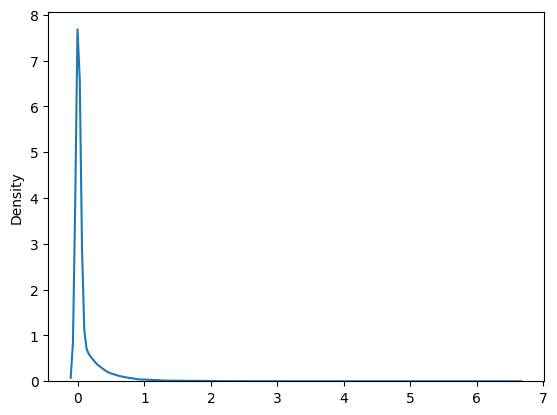

In [38]:
import seaborn as sns
sns.kdeplot(adata_i.layers["norm_log1p"][3])

In [42]:
microarray_ids = data_info.query("organism == 'Homo sapiens' & library_strategy == 'Microarray'")["dsaid"].to_list()
print(f"Nº of human microarray datasets: {len(microarray_ids)}")

Nº of human microarray datasets: 4468


In [100]:
rnd_ma = random.sample(microarray_ids, 50)


adatas_ma = []

for i, dsaid_i in enumerate(tqdm(rnd_ma)):
    _data = load_raw_data(dsaid_i)  # IDs in col 0, rest numeric
    try:
        _data_matrix = np.asarray(_data)

        # First column are gene IDs (because rows are genes)
        gene_ids = _data_matrix[:, 0].astype(str)

        # Expression values: genes x samples
        expr_gxS = _data_matrix[:, 1:].astype(float)

        # Make sample IDs for columns (if you don't have real ones)
        sample_ids = [f"{dsaid_i}_s{j}" for j in range(expr_gxS.shape[1])]

        # Transpose to samples x genes
        expr_SxG = expr_gxS.T

        adata = ad.AnnData(
            X=expr_SxG,
            obs=pd.DataFrame(index=sample_ids),
            var=pd.DataFrame(index=gene_ids),
        )
        adata.obs["dataset_id"] = dsaid_i

        adatas_ma.append(adata)

    except Exception as e:
        print(f"Error processing dataset {dsaid_i}: {e}")
        continue



  0%|          | 0/50 [00:00<?, ?it/s]/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  2%|▏         | 1/50 [00:00<00:05,  8.64it/s]/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  4%|▍         | 2/50 [00:01<00:38,  1.24it/s]/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  6%|▌         | 3/50 [00:02<00:34,  1.38it/s]/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable

In [ ]:
adatas_ma[10].X

IndexError: list index out of range

In [101]:
import scanpy as sc

adatas_ma_processed = []

for adata in adatas_ma:
    adata_i = adata.copy()

    # keep raw counts
    adata_i.layers["counts"] = adata_i.X.copy()

    # normalize + log1p
    sc.pp.normalize_total(adata_i, target_sum=10000)
    sc.pp.log1p(adata_i)

    # save normalized/log1p into a layer
    adata_i.layers["norm_log1p"] = adata_i.X.copy()

    # restore X back to counts
    adata_i.X = adata_i.layers["counts"]

    # add binning based on the normalized/log1p values
    add_binning_to_adata_like_preprocessor(
        adata_i,
        n_bins=51,
        source_layer="norm_log1p"
    )

    adatas_ma_processed.append(adata_i)


/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-pac

ValueError: Assuming non-negative data, but got min value -0.038056128278533746.

<Axes: ylabel='Density'>

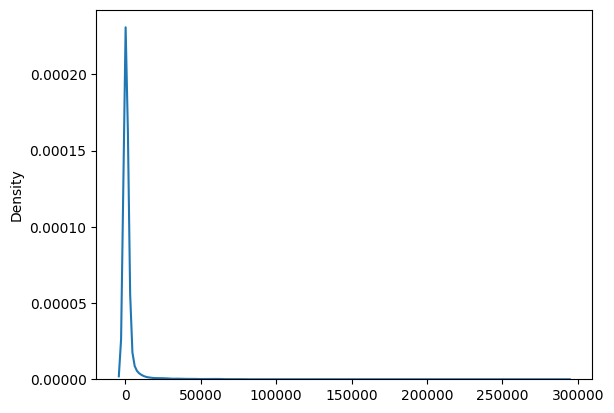

In [ ]:
sns.kdeplot(2**(adata_i.X[0]))

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
i = 8
sns.kdeplot(adata_i.X[i])
plt.show()
sns.kdeplot(adata_i.layers["norm_log1p"][i])
plt.show()

IndexError: index 8 is out of bounds for axis 0 with size 8

In [79]:
import numpy as np
from scipy.sparse import issparse

def _digitize_like_preprocessor(x: np.ndarray, bins: np.ndarray, side: str = "both") -> np.ndarray:
    """Same as the Preprocessor's _digitize()."""
    left_digits = np.digitize(x, bins)  # 0..len(bins)
    if side == "one":
        return left_digits.astype(np.int64)

    right_digits = np.digitize(x, bins, right=True)
    rands = np.random.rand(len(x))
    digits = rands * (right_digits - left_digits) + left_digits
    return np.ceil(digits).astype(np.int64)

def bin_matrix_like_preprocessor(X, n_bins: int):
    """
    Replicates Preprocessor step-6 binning:
    - per-row quantile bins computed on NON-ZERO entries
    - zeros stay 0
    - outputs digits in [0..n_bins-1] with non-zeros in [1..n_bins-1]
    - stores per-row bin_edges = [0] + bins
    """
    if not isinstance(n_bins, int) or n_bins < 2:
        raise ValueError("n_bins must be an int >= 2")

    X = X.toarray() if issparse(X) else np.asarray(X)

    if X.size == 0:
        return X.astype(np.int64), np.zeros((X.shape[0], n_bins), dtype=X.dtype)

    if X.min() < 0:
        raise ValueError(f"Assuming non-negative data, but got min value {X.min()}.")

    binned_rows = []
    bin_edges = []

    for row in X:
        if row.max() == 0:
            binned_rows.append(np.zeros_like(row, dtype=np.int64))
            bin_edges.append(np.array([0] * n_bins))
            continue

        non_zero_ids = row.nonzero()
        non_zero_row = row[non_zero_ids]

        bins = np.quantile(non_zero_row, np.linspace(0, 1, n_bins - 1))
        non_zero_digits = _digitize_like_preprocessor(non_zero_row, bins, side="both")

        # Same assertions as Preprocessor
        assert non_zero_digits.min() >= 1
        assert non_zero_digits.max() <= n_bins - 1

        binned_row = np.zeros_like(row, dtype=np.int64)
        binned_row[non_zero_ids] = non_zero_digits

        binned_rows.append(binned_row)
        bin_edges.append(np.concatenate([[0], bins]))

    return np.stack(binned_rows), np.stack(bin_edges)

def add_binning_to_adata_like_preprocessor(
    adata,
    n_bins: int,
    source_layer: str | None = None,   # None means adata.X
    result_binned_key: str = "X_binned",
    bin_edges_key: str = "bin_edges",
):
    X_source = adata.layers[source_layer] if source_layer is not None else adata.X

    X_binned, edges = bin_matrix_like_preprocessor(X_source, n_bins=n_bins)

    adata.layers[result_binned_key] = X_binned
    adata.obsm[bin_edges_key] = edges
    return adata


In [80]:
add_binning_to_adata_like_preprocessor(adata_i, n_bins=51, source_layer="norm_log1p")

AnnData object with n_obs × n_vars = 8 × 21941
    obs: 'dataset_id'
    uns: 'log1p'
    obsm: 'bin_edges'
    layers: 'counts', 'norm_log1p', 'X_binned'

<Axes: ylabel='Density'>

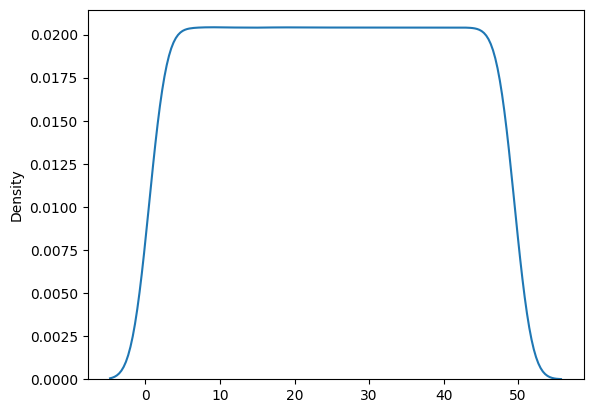

In [82]:
sns.kdeplot(adata_i.layers["X_binned"][0])